<a href="https://colab.research.google.com/github/LakshmiPriya190706/Behcet-s-disease-detection/blob/main/Behcet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive to access your dataset
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
dataset_path = '/content/drive/MyDrive/Behcet detection'


In [ ]:
image_size = (224, 224)
batch_size = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,  # 80% training, 20% validation
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 168 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze weights

model = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(train_data, validation_data=val_data, epochs=10)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.3431 - loss: 1.0023 - val_accuracy: 0.6500 - val_loss: 0.7345
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 886ms/step - accuracy: 0.5729 - loss: 0.7584 - val_accuracy: 0.6250 - val_loss: 0.6040
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 933ms/step - accuracy: 0.5523 - loss: 0.7730 - val_accuracy: 0.7000 - val_loss: 0.5640
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5095 - loss: 0.9068 - val_accuracy: 0.7250 - val_loss: 0.5798
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 986ms/step - accuracy: 0.4968 - loss: 0.8252 - val_accuracy: 0.6750 - val_loss: 0.6024
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 824ms/step - accuracy: 0.6619 - loss: 0.6398 - val_accuracy: 0.6750 - val_loss: 0.5806
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 979ms/step - accuracy: 0.6099 - loss: 0.6989 - val_accuracy: 0.7500 - val_loss: 0.5443
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5635 - loss: 0.6856 - val_accuracy: 0.70

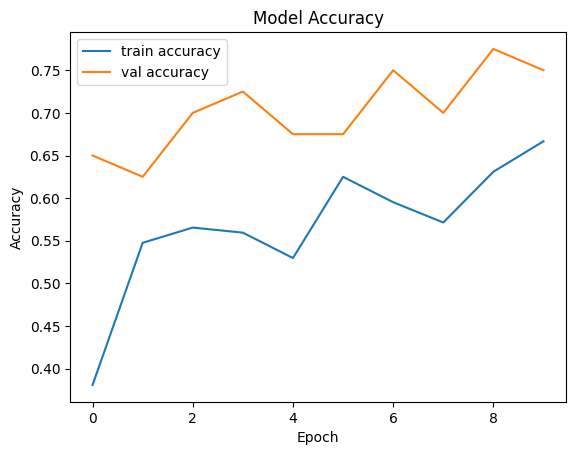

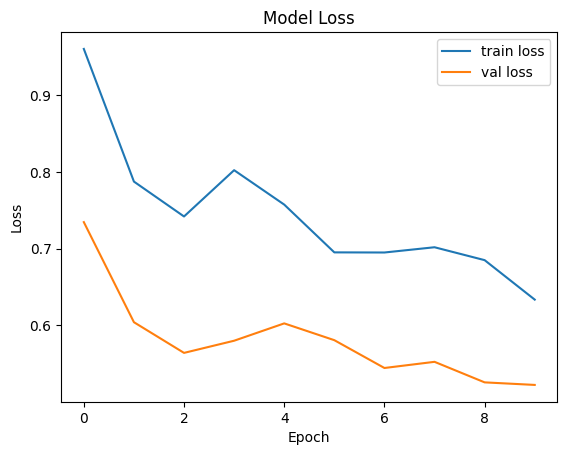

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Evaluate on validation
val_loss, val_acc = model.evaluate(val_data)
print(f'Validation Accuracy: {val_acc * 100:.2f}%')


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 0.8109 - loss: 0.4866
Validation Accuracy: 82.50%


In [ ]:
model.save('behcet.keras')  # Saves in the new format


In [ ]:
img_height = 224
img_width = 224


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Set the image size (same as used during training)
img_height = 224
img_width = 224

# Load and preprocess image
img_path = '/content/hand.jpg'  # Use your actual path
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize

# Make prediction
prediction = model.predict(img_array)

# Interpret the prediction (adjust for your number of classes or threshold)
if prediction[0] > 0.5:
    print("Prediction: Normal")
else:
    print("Prediction: Affected (Possible Behçet's Disease)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prediction: Normal


So the model maps:

affected → 0

normal → 1